# <h1><center>Lógica Computacional 2024/2025 - TP3</center></h1>

 **Grupo 6**
 * Cláudia Faria, a105531
 * Patrícia Bastos, a102502

In [ ]:
!yes | pip install pysmt
!apt-get install libgmp3-dev
!yes | pysmt-install --z3 --msat

In [ ]:
from pysmt.shortcuts import *
from pysmt.typing import INT

## **Exercício 2**

### Enunciado

Relativo ao programa do problema anterior,

a. Construa um “Control Flow Automaton (CFA)” que determina este programa. Identifique os locais e as transições/ramos.  Numa <u>abordagem orientada às pré-condições</u>  identifique os transformadores de predicados associados aos vários locais e os “switches” associados aos vários ramos.

b. Construa em `z3` o sistema de equações que representa o comportamento deste sistema dinâmico sob o ponto de vista da prova de segurança e verifique a segurança do programa através da resolução (total ou parcial) deste sistema.

> sugere-se (não é obrigatório mas é valorizado !), na alínea (a), uma representação do CFA através de  um grafo orientado  implementado  em `networkx`  e a sua compilação para o sistema de equações.

Programa:

O algoritmo estendido de Euclides (EXA) aceita dois inteiros constantes  $\,a,b>0\,$  e devolve inteiros $r,s,t\,$ tais que  $\,a*s + b*t = r\,$  e  $\,r = \gcd(a,b)\,$.

Para além das variáveis $\,r,s,t\,$ o código requer 3 variáveis adicionais $\,r',s',t'\,$ que representam os valores de $\,r,s,t\,$ no “próximo estado”.


```
INPUT  a, b
assume  a > 0 and b > 0
r, r', s, s', t, t' = a, b, 1, 0, 0, 1

0: while r' != 0
1:   q = r div r'
2:   r, r', s, s', t, t' = r', r − q × r', s', s − q × s', t', t − q × t'
3: stop

OUTPUT r, s, t

```

Para simplificar o uso de r', s' e t' nas resoluções que se seguem, estes serão referidos como rl, sl e tl , respetivamente.

### a. Construa um “Control Flow Automaton (CFA)” que determina este programa. Identifique os locais e as transições/ramos.  Numa <u>abordagem orientada às pré-condições</u>  identifique os transformadores de predicados associados aos vários locais e os “switches” associados aos vários ramos.

####Definição do CFA


**Locais**
*  init: inicialização do sistema
*  do: representa o loop enquanto $rl \neq 0$
*  update: atualização das variáveis $q, r, rl, s, sl, t, tl$
*  stop: condição de saída do programa, quando $ rl = 0$
*  error: condição de erro, quando $r = 0$ ou $rl \neq (s \times a) + (tl \times b)$

---

$system = (a > 0) ∧ (b > 0) ∧ (r = a) ∧ (rl = b) ∧ (s = 1) ∧ (sl = 0) ∧ (t = 0) ∧ (tl = 1) ∧ ¬ do $

$do = (rl = 0 → stop) ∧ ((rl \neq 0) → update)$

$update = (WP_{update}\;((r = 0 ∨ r = a × s + b × t) → error) ∧ (¬(r = 0 ∨ r = a × s + b × t) → do))$




---



**Transformadores de Predicados**

Os transformadores descrevem como os estados mudam ao longo das transições.
Têm como objetico calcular a condição inicial mais fraca que deve ser verdadeira para garantir que uma condição final específica seja satisfeita após a execução do programa.



* **system**:
$$WP_{system}\,(Q) ≡ (a > 0) ∧ (b > 0) ∧ (r = a) ∧ (rl = b) ∧ (s = 1) ∧ (sl = 0) ∧ (t = 0) ∧ (tl = 1) ∧ WP_{do}\,(Q)$$

* **do**:

$$WP_{do}\,(Q) ≡ (rl = 0 → WP_{stop}\,(Q)) ∧ (rl \neq 0 → WP_{update}\,(Q))$$

* **update**:

$$WP_{update}\,(Q) ≡ ((r = 0 ∨ rl \neq (s \times a) + (tl \times b)) → WP_{error}\,(Q)) ∧ (\neg(r = 0 ∨ rl \neq (s \times a) + (tl \times b)) → Q(q/div(r,rl),r/rl, rl/r - q \times rl, s/sl, sl/s - q \times sl, t/tl, tl/t - q \times tl))$$

* **stop**:

$$WP_{stop}\,(Q) ≡ Q$$

* **error**:
$$WP_{error}(Q) ≡ False$$


**Switches**

Os switches representam as condições necessárias para as transições.

* **switch → do**:

$$SW_{system,do}\, = (a > 0) ∧ (b > 0)$$

* **do → update**:

$$SW_{do,update}\, = (rl \neq 0)$$

* **do → stop**:

$$SW_{do,stop}\, = (rl = 0)$$

* **update → error**:

$$SW_{update,error}\, = (r = 0 ∨ rl \neq (s \times a) + (tl \times b))$$

* **update → do**:

$$SW_{update,do} = ¬\,(r = 0 ∨ rl \neq (s \times a) + (tl \times b))$$

#### Representação do CFA através de um grafo

In [12]:
from os import O_DIRECT
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

a = Symbol("a", INT)
b = Symbol("b", INT)
r = Symbol("r", INT)
rl = Symbol("rl", INT)
s = Symbol("s", INT)
sl = Symbol("sl", INT)
t = Symbol("t", INT)
tl = Symbol("tl", INT)
q = Symbol("q", INT)

# Nodes: label-annotation tuples.
nodes = [("system", "havoc a,b"),
         ("do", "skip"),
         ("update", {q: Div(r, rl), r: rl, rl: Minus(r, Times(q, rl)), s: sl, sl: Minus(s, Times(q, sl)), t: tl, tl: Minus(t, Times(q,tl))}),
         ("error", "skip"),
         ("stop", "skip")]

# Edges: source-target-condition tuples.
edges = [("system", "do", And(GT(a, Int(0)), GT(b, Int(0)), Equals(r, a), Equals(rl, b), Equals(s, Int(1)), Equals(sl, Int(0)), Equals(t, Int(0)), Equals(tl, Int(1)))),
         ("do", "stop", Equals(rl, Int(0))),
         ("do", "update", NotEquals(rl, Int(0))),
         ("update", "do", Not(Or(Equals(r, Int(0)), Not(Equals(r, Plus(Times(a,s),Times(b,t))))))),
         ("update", "error", Or(Equals(r, Int(0)), Not(Equals(r, Plus(Times(a,s),Times(b,t))))))]

for label, annotation in  nodes:
    G.add_node(label, annotation = annotation)

for source, target, condition in edges:
    G.add_edge(source, target, condition = condition)

In [13]:
def clean_condition_label(condition, width=40): #Limpar numero de bits e outros erros visuais
    label = serialize(condition)
    return label

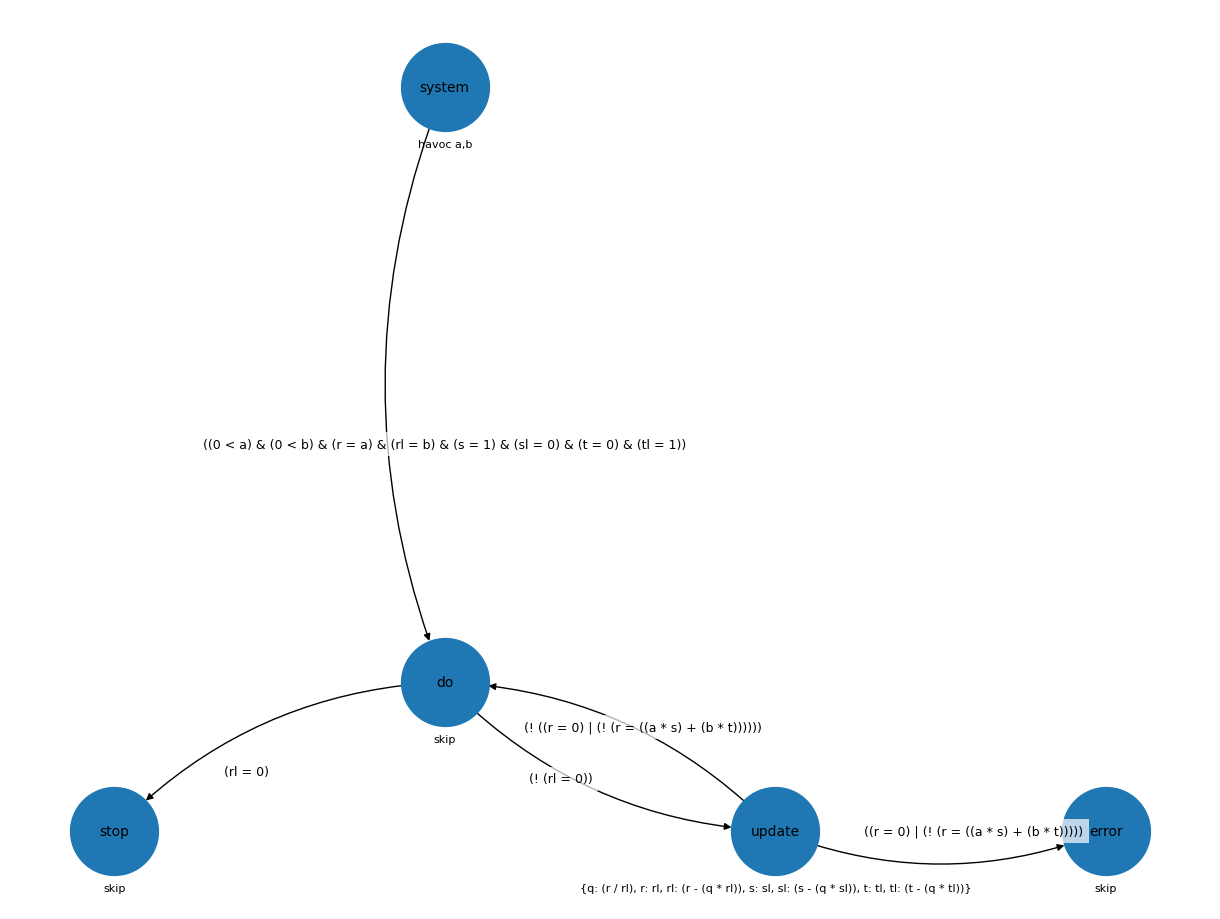

In [14]:
pos = {
    "system": (3, 10),
    "do": (3, 2),
    "update": (5, 0),
    "error": (7, 0),
    "stop": (1, 0)
}

edge_pos_offsets = {
    ("do", "update"): (-0.5, -0.1),   #Ajustar rótulo para evitar sobreposição
    ("update", "do"): (0.4, 0.2),     #Ajustar rótulo para evitar sobreposição
}


plt.figure(figsize=(12, 9))
nx.draw(G, pos  = pos, with_labels = True, node_size = 4000, font_size = 10, connectionstyle="arc3,rad=0.2")
label = serialize(condition)



for (u, v, d) in G.edges(data=True):
    #Rotulação padrão
    label = d["condition"]
    label_pos = 0.6  #Posição do rótulo ao longo da aresta
    #ajustar o display
    label = clean_condition_label(d["condition"])

    #Ajuste para arestas específicas
    offset = edge_pos_offsets.get((u, v), (0, 0))
    label_pos_adjusted = (
        pos[u][0] + (pos[v][0] - pos[u][0]) * label_pos + offset[0],
        pos[u][1] + (pos[v][1] - pos[u][1]) * label_pos + offset[1],
    )

    #Adicionar rótulo com fundo opaco
    plt.text(
        label_pos_adjusted[0], label_pos_adjusted[1], label,
        fontsize=9, color="black", ha="center", va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7)  #Fundo opaco
    )

annotations = nx.get_node_attributes(G, 'annotation')
for node, annotation in annotations.items():
    x, y = pos[node]
    plt.annotate(annotation, (x, y - 0.7), fontsize=8, ha='center', va='top')

plt.show()

###b. Construa em `z3` o sistema de equações que representa o comportamento deste sistema dinâmico sob o ponto de vista da prova de segurança e verifique a segurança do programa através da resolução (total ou parcial) deste sistema.

Tendo sido o sistema de equações contruído em z3 na alínea anterior sobra apenas verificar a segurança do programa.
Para tal é usada a função graph_safety que tem como argumentos o grafo que representa o programa $G$ e o número de iterações $n$.

In [15]:
def graph_safety(G, n):
    print(f"> A testar {n} iterações.")
    with Solver(name = "z3") as solver:
      error = TRUE()
      stop = FALSE()

      do = FALSE()


      for source, target, data in G.edges(data = True):
          if source == "system" and target == "do":
              guarda = data["condition"]


      for i in range(n):
          system = And(guarda, do)
          if solver.solve([system]):
            print(f"> Iteração {i}: sistema inseguro.")
            return

          clauses = []
          for source, target, data in G.edges(data = True):
              if source == "do":
                condition = data["condition"]
                if target == "error":
                  clauses.append(Implies(condition, error))
                elif target == "stop":
                  clauses.append(Implies(condition, stop))
                else:
                  sub = G.nodes[target]["annotation"]
                  atrib = substitute(do, sub)
                  clauses.append(Implies(condition, atrib))

          new_do = And(clauses)

          # Tentar generalizar.
          R = And(do, Not(new_do))
          L =  And(new_do, Not(do))
          if solver.is_unsat(Or(R, L)):
              # do_n <-> do_{n-1}
              print(f"> Iteração {i}: sistema seguro.")
              return

          do = Or(do, new_do)

      print("> Não foram encontrados estados inseguros.")

graph_safety(G, 10)

> A testar 10 iterações.
> Iteração 0: sistema seguro.
